****AKLT investigation with my own MPS instance****

First we define the AKLT state

In [2]:
from base import MPS, SpinOperator
import torch
from math import sqrt
import numpy as np

sp = torch.tensor([[0.,1.],[0.,0.]], dtype=torch.complex128,device='cuda')
sm = torch.tensor([[0.,0.],[1.,0.]], dtype=torch.complex128,device='cuda')
sz = torch.tensor([[1.,0.],[0.,-1.]], dtype=torch.complex128,device='cuda')

A = torch.zeros(2, 3, 2, dtype=torch.complex128,device='cuda')
A[:,0,:] = sp
A[:,1,:] = -sz / sqrt(2)
A[:,2,:] = -sm

L = 100
tensors = [A.clone() for _ in range(L)] # deep copy
bond_dims = [2]*(L+1)
aklt = MPS(L, 3, bond_dims, init_state=tensors, dtype=torch.complex128)

First let us see that there is no magnetization.

In [3]:
m = np.zeros((3, L)) 
S = SpinOperator(3).data # spin 1 operators Sx, Sy, Sz

for i in range(L): # each site
    for j in range(3): # each spin component
        m[j, i] = aklt.expectation({i: S[j]}).real
print("Magnetization:", np.max(np.abs(m)))

Magnetization: 1.1102230246251565e-16


Next we measure the correlation

In [4]:

zzcorr = np.zeros(L)
for i in range(L):
    res = aklt.expectation({i: S[2], 50: S[2]})
    # convert complex result to real float
    if isinstance(res, torch.Tensor):
        val = res.cpu().real.item()
    else:
        val = float(np.real(res))
    zzcorr[i] = val


Slope: -1.0986122886698493 compared with ln(1/3) = -1.0986122886681098


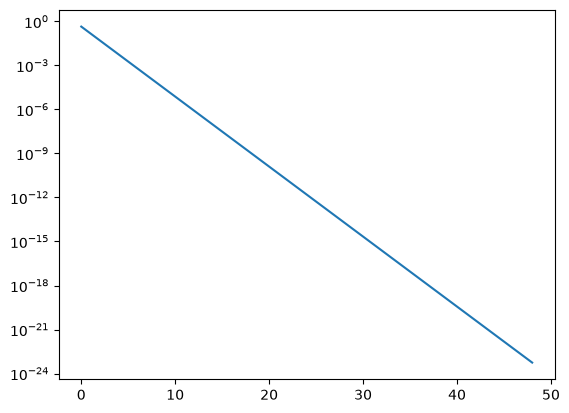

In [5]:
import matplotlib.pyplot as plt
plt.plot(range(L//2-1), abs(zzcorr)[L//2+1:])
plt.yscale('log')

from scipy.stats import linregress
x = np.arange(1, L//2)
y = np.log(abs(zzcorr)[L//2+1:])
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print("Slope:", slope, 'compared with ln(1/3) =', np.log(1/3))


Finally String order:

In [6]:
Ostr = torch.diag(torch.tensor([-1,1,-1], dtype=torch.complex128,device='cuda'))

for j in range(1,L):
    string_order = {
    0: S[2]
}
    for i in range(1,j):
        string_order[i] = Ostr.clone()
    string_order[j] = S[2]
    print(f"String order parameter <Sz(0)O^{j-1}Sz({j})> = {aklt.expectation(string_order)}")
    # converges to -4/9

String order parameter <Sz(0)O^0Sz(1)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^1Sz(2)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^2Sz(3)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^3Sz(4)> = (-0.44444444444444686+0j)
String order parameter <Sz(0)O^4Sz(5)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^5Sz(6)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^6Sz(7)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^7Sz(8)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^8Sz(9)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^9Sz(10)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^10Sz(11)> = (-0.44444444444444686+0j)
String order parameter <Sz(0)O^11Sz(12)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^12Sz(13)> = (-0.44444444444444686+0j)
String order parameter <Sz(0)O^13Sz(14)> = (-0.444444444444447+0j)
String order parameter <Sz(0)O^14Sz(15)> = (-0.44444444444444686+0j)
String